In [ ]:
# linear regression for one variable to predict profits of a restuarant franchise


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from utils import *
import copy
import math
%matplotlib inline

In [ ]:
#Problem statement
#As a CEO of a restuarant franchise you are considering expanding the business to cities that may give higher profits
# The chain restuarant has existing branches in different cities, and 
# you have data for profits and populations from the cities
# You also have data on cities that are candidates for a new restaurant
# For these cities, you have the city population


In [ ]:
#import the data set - has 2 features (population and monthly profits)
x_train, y_train = load_data()

In [ ]:
#go through the dataset to familiarize yourself - ndarray that contains decimal values > 0, 
# 
#print x_train - representing the city population
print(f'Type of x_train: ', type(x_train))
print(f'First five elements of x_train are :\n', x_train[:5])

Type of x_train:  <class 'numpy.ndarray'>
First five elements of x_train are :
 [6.1101 5.5277 8.5186 7.0032 5.8598]


In [ ]:
#print y_train - represent rest. avg monthly profits in units of $10000
print(f'Type of y_train: ', type(y_train))
print(f'First five elements of y_train are:\n', y_train[:5])

Type of y_train:  <class 'numpy.ndarray'>
Firts five elements of y_train are:
 [17.592   9.1302 13.662  11.854   6.8233]


In [ ]:
#check dimensions of the variables -  1D ndarray of 97 data points
print(f'The shape of x_train is: ', x_train.shape)
print(f'The shape of y_train is: ', y_train.shape)
print(f'Number of training examples (m): ', len(x_train))

The shape of x_train is:  (97,)
The shape of y_train is:  (97,)
Number of training examples (m):  97


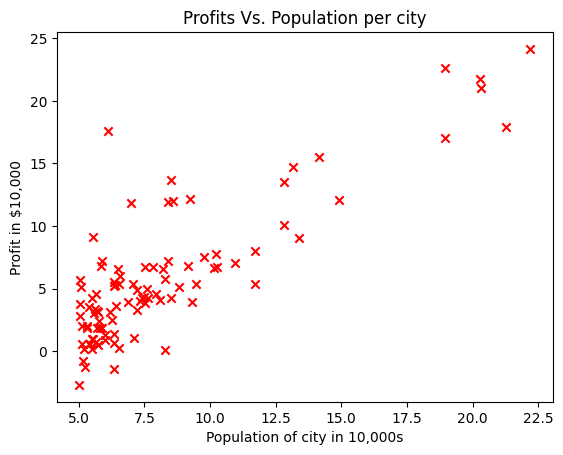

In [8]:
#visualize the data
#create a scatter plot of the data. 
plt.scatter(x_train, y_train, marker='x', c='r')

#set the title
plt.title(f'Profits Vs. Population per city')

#set y-xis label
plt.ylabel(f'Profit in $10,000')

#set the x-axis label
plt.xlabel(f'Population of city in 10,000s')
plt.show()



In [18]:
#compute cost
def compute_cost(x, y, w, b):
    ''' 
    Computes the cost function for linear regression

    Args:
     x (ndarray): shape (m,) Input to the model (Population of cities)
     y (ndarray): shape (m,) Label (Actual profits for the cities)
     w, b (scalar): Parameters of the model

    Returns:
     total_coat (float): The cost of using w,b as the parameters for linear regression to fit 
      the data points in x and y
    '''
    #number of training examples
    m = x.shape[0]

    #return the `total_cost`
    total_cost = 0

    #variable to keep track of the sum of cost from each example
    cost_sum = 0

    #loop over training examples
    for i in range(m):
        f_wb = w * x[i] + b  #prediction
        cost = (f_wb - y[i]) ** 2 #difference between prediction and actual value
        cost_sum = cost_sum + cost #add all training examples
    #get the total cost as the sum divided by (2*m)
    total_cost = (1 / (2*m)) * cost_sum

    return total_cost




In [21]:
#compute cost with some initial values for parameter w, b --> check whether the above implementation 
 # is functioning well

initial_w = 2
initial_b = 1

cost = compute_cost(x_train, y_train, initial_w, initial_b)
print(type(cost))
print(f'Cost at initial w: {cost:.3f}' )

#public tests
from public_tests import *

compute_cost_test(compute_cost)

<class 'numpy.float64'>
Cost at initial w: 75.203
All tests passed!


In [24]:
#Gradient descent
def compute_gradient(x, y, w, b):
    ''' 
    Computes the gradient for linear regression
    Args:
     x (ndarray): shape (m,) Input to the model (Population of cities)
     y (ndarray): shape (m,) Label (Actual profits for the cities)
     w, b (scalar): Parameters for the model

    Returns:
     dj_dw (scalar): The gradient of the cost with respect to the parameters w
     dj_db (scalar): The gradient of the cost with respect to the parameter b
    '''

    #number of training examples
    m = x.shape[0]

    #return the following variables
    dj_dw = 0
    dj_db = 0

    #loop over the m examples
    for i in range(m):
        f_wb = w * x[i] + b # prediction `f_wb`for the ith example
        dj_dw_i = (f_wb - y[i]) * x[i] #gradient for w from the ith example
        dj_db_i = f_wb - y[i]  # gradient for b from the ith example
        #update dj_db
        dj_db += dj_db_i

        #update dj_dw
        dj_dw += dj_dw_i

    #divide both dj_dw and dj_db by m
    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db


In [25]:
#check /test the above implementation
initial_w = 0
initial_b = 0

tmp_dj_dw, tmp_dj_db = compute_gradient(x_train, y_train, initial_w, initial_b)
print(f'Gradient at initial w, b (zeros): ', tmp_dj_dw, tmp_dj_db)

compute_gradient_test(compute_gradient)

Gradient at initial w, b (zeros):  -65.32884974555672 -5.83913505154639
Using X with shape (4, 1)
All tests passed!


In [26]:
#compute and display cost and gradient with non-zero w
test_w = 0.2
test_b = 0.2
tmp_dj_dw, tmp_dj_db = compute_gradient(x_train, y_train, test_w, test_b)

print(f'Gradient at test w, b:', tmp_dj_dw, tmp_dj_db)

Gradient at test w, b: -47.41610118114435 -4.007175051546391


In [27]:
#batch gradient descent testing
def gradient_descent(x, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters):
    ''' 
    Performs batch gradient descent to learn theta. Updates theta bu=y taking num_iters 
     gradient steps with learning rate alpha

    Args:
     x: (ndarray): shape (m,)
     y : (ndarray): shape (m,)
     w_in, b_in : (scalar): Initial values of parameters of the model
     cost_fucntion : function to compute cost
     gradient_fucntion : function to compute the gradient
     alpha : (float) Learning rate
     num_iters : (int) number of iterations to run the gradient descent
    
    Returns:
     w : (ndarray): Shape(1,) Updated values of parameters of the model after running gradient descent
     b : (scalar) Updated value of parameter of the model after running gradient descent

    '''
    #number of training examples
    m = len(x)

    #an array to store cost J and w's at each iteration - for graphing later
    J_history = []
    w_history = []

    w = copy.deepcopy(w_in) #avoid modifying global w within function
    b = b_in

    for i in range(num_iters):
        #calculate the gradient and update the parameters
        dj_dw, dj_db = gradient_function(x, y, w, b )

        #update parameters using w, b, alpha, and gradient 
        w = w -alpha * dj_dw
        b = b - alpha * dj_db

        #save cost J at each iteration
        if i<100000:  #prevent resource exhaustion
            cost = cost_function(x, y, w, b)
            J_history.append(cost)
        
        #print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters/10)==0:
            w_history.append(w)
            print(f'Iteration {i:4}: Cost {float(J_history[-1]):8.2f}  ')

    return w, b, J_history, w_history  #return w and J,w history for graphing


In [28]:
#run/test the above implementation
initial_w = 0
initial_b = 0

#some gradient descent settings
iterations = 1500
alpha = 0.01

w, b, _, _ = gradient_descent(x_train, y_train, initial_w, initial_b, compute_cost, compute_gradient,
                              alpha, iterations)
print(f'w, b found by gradient descent: ', w, b )


Iteration    0: Cost     6.74  
Iteration  150: Cost     5.31  
Iteration  300: Cost     4.96  
Iteration  450: Cost     4.76  
Iteration  600: Cost     4.64  
Iteration  750: Cost     4.57  
Iteration  900: Cost     4.53  
Iteration 1050: Cost     4.51  
Iteration 1200: Cost     4.50  
Iteration 1350: Cost     4.49  
w, b found by gradient descent:  1.166362350335582 -3.63029143940436


In [29]:
#to run through the entire training examples and calculate prediction for each training example
m = x_train.shape[0]
predicted = np.zeros(m)

for i in range(m):
    predicted[i] = w * x_train[i] + b

Text(0.5, 0, 'Population of city in 10,000s')

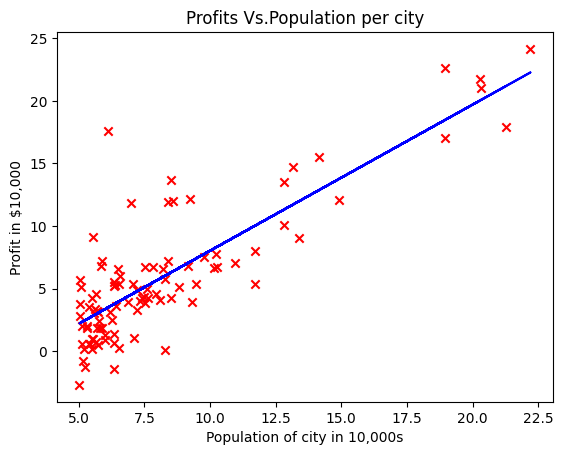

In [30]:
#plot the linear fit
plt.plot(x_train, predicted, c='b')

#create scatter plot of the data
plt.scatter(x_train, y_train, marker='x', c='r')

#set title
plt.title(f'Profits Vs.Population per city')

#set the y-axis label
plt.ylabel('Profit in $10,000')

#set the x-axis label
plt.xlabel('Population of city in 10,000s')

In [ ]:
#predicting  profit for areas with 35,000(np.array([3.5])) and 70,000(np.array([7.5])) people 
predict1 = 3.5 *  w + b
print(f'For population = 35,000, we predict a profit of $%.2f' % (predict1*10000))

predict2 = 7.0 * w + b
print(f'For population = 70,000, we predict a profit of $%.2f' % (predict2*10000))

For population = 35,000, we predict a profit of $4519.77
Forpopulation = 70,000, we predict a profit of $45342.45
